# 1. Описание задачи

## Бизнес-контекст

Разрабатывается мобильный мессенджер с функцией умных подсказок. Во время набора сообщения приложение должно предлагать пользователю наиболее вероятное следующее слово.

Примеры работы функции:

| Введённый текст | Возможное следующее слово |
|---|---|
| `the president of the` | `united` |
| `i want to` | `go` |
| `the weather today is` | `sunny` |
| `new york is a` | `city` |

Такая функция применяется в мобильных клавиатурах, мессенджерах, поисковых строках и голосовых помощниках.

## Цель проекта

Цель проекта — обучить и сравнить несколько архитектур нейронных сетей для предсказания следующего слова, а затем определить, какая из них лучше подходит для использования на мобильном устройстве.

При выборе модели необходимо учитывать:

- качество предсказаний;
- количество параметров;
- размер модели;
- скорость обучения;
- скорость получения предсказания.

## Постановка задачи

Модель получает последовательность токенов и должна предсказать следующий токен.

Например:

```text
Вход:    the cat sat on the
Таргет:  cat sat on the mat

Таким образом, задача предсказания следующего слова рассматривается как задача многоклассовой классификации. Модель рассчитывает вероятности всех слов из словаря, а правильным классом является фактическое следующее слово.

In [1]:
%pip install -v numpy pandas matplotlib seaborn tqdm datasets transformers

Using pip 26.2.1 from d:\МИФИ_учеба\3_семестр\02_Работа_с_изображениями_и_текстами\01_проект\.venv\Lib\site-packages\pip (python 3.14)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# %pip install --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu132

In [3]:
# %pip install "fsspec[http]==2026.6.0"

In [ ]:
import sys
import math
import time
import random
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM

d:\МИФИ_учеба\3_семестр\02_Работа_с_изображениями_и_текстами\01_проект\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
SEED = 42


def set_seed(seed: int = 42) -> None:
    """Фиксирует генераторы случайных чисел."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# True — быстрый локальный запуск
# False — итоговый запуск на полном датасете
FAST_RUN = True

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {DEVICE}")
print(f"Быстрый режим: {FAST_RUN}")

if torch.cuda.is_available():
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")

Python: 3.14.3
PyTorch: 2.14.1+cu132
Устройство: cuda
Быстрый режим: True
Видеокарта: NVIDIA GeForce RTX 5060 Ti


# 2. Загрузка WikiText-2

Для обучения и оценки моделей используется датасет **WikiText-2** — набор англоязычных текстов из статей Википедии.

Датасет имеет стандартное разделение:

- `train` — обучение моделей;
- `validation` — оценка качества после каждой эпохи;
- `test` — итоговая проверка лучших моделей.

На этом этапе загрузим данные, проверим их структуру и выведем несколько примеров. Обучающая, валидационная и тестовая части не будут смешиваться.

In [10]:
DATASET_NAME ="Salesforce/wikitext"
DATASET_CONFIG = "wikitext-2-raw-v1"

dataset = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG
)

dataset

Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 891345.90 examples/s]


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

# 3. Анализ данных

Проведём разведочный анализ WikiText-2. Определим количество пустых и непустых текстовых блоков, приблизительное число слов и распределение длин текстов.

Это позволит оценить объём данных и выбрать подходящие параметры для формирования обучающих последовательностей.

In [11]:
required_splits = {"train", "validation", "test"}

assert required_splits.issubset(dataset.keys()), (
    "В датасете отсутствует один из обязательных разделов"
)

for split_name in ["train", "validation", "test"]:
    split = dataset[split_name]

    print(f"{split_name}:")
    print(f"  количество строк: {len(split):,}")
    print(f"  столбцы: {split.column_names}")

train:
  количество строк: 36,718
  столбцы: ['text']
validation:
  количество строк: 3,760
  столбцы: ['text']
test:
  количество строк: 4,358
  столбцы: ['text']


In [12]:
split_sizes = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(dataset["train"]),
            len(dataset["validation"]),
            len(dataset["test"]),
        ],
    }
)

split_sizes

,split,rows
0,train,36718
1,validation,3760
2,test,4358


Датасет успешно загружен и содержит три обязательные части:

- обучающая выборка - 36 718 строк;
- валидационная выборка - 3 760 строк;
- тестовая выборка - 4 358 строк.

Каждая часть содержит один столбец `text` с текстовыми блоками. Обучающая выборка является самой большой, поскольку используется для настройки параметров моделей. Валидационная выборка будет применяться для контроля качества во время обучения, а тестовая — для окончательной оценки лучших моделей.

Количество строк не соответствует количеству слов или предложений: одна строка может быть заголовком, абзацем либо быть пустой. Поэтому фактический объём текстовых данных будет определён на этапе разведочного анализа.

In [13]:
def show_text_examples(split, number_of_examples=5):
    """Выводит несколько непустых текстов из выбранной части датасета."""
    
    shown = 0

    for row in split:
        text = row["text"].strip()

        if not text:
            continue

        shown += 1
        print(f"Пример {shown}:")
        print(text[:500])
        print("-" * 80)

        if shown == number_of_examples:
            break


show_text_examples(
    dataset["train"],
    number_of_examples=5
)

Пример 1:
= Valkyria Chronicles III =
--------------------------------------------------------------------------------
Пример 2:
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and fo
--------------------------------------------------------------------------------
Пример 3:
The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Characte

### Вывод по примерам текстов

В WikiText-2 представлены не только обычные текстовые абзацы, но и заголовки статей и разделов, отмеченные символами `=`. Строки датасета не всегда соответствуют отдельным предложениям.

В текстах сохраняются регистр, пунктуация, числа, имена собственные и неанглийские символы. Пустые строки необходимо исключить перед формированием последовательностей.

Перед обучением потребуется выполнить минимальную предобработку:

- удалить пустые строки;
- обработать служебные символы заголовков;
- определить правила токенизации слов и знаков препинания;
- добавить специальный токен конца текстового блока.

Сильную очистку текста проводить не следует, поскольку пунктуация и структура текста содержат полезную информацию для предсказания следующего слова.

In [16]:
dataset_statistics = []

for split_name in ["train", "validation", "test"]:
    texts = dataset[split_name]["text"]

    non_empty_texts = [
        text for text in texts
        if text.strip()
    ]

    number_of_words = sum(
        len(text.split())
        for text in non_empty_texts
    )

    number_of_characters = sum(
        len(text)
        for text in non_empty_texts
    )

    dataset_statistics.append(
        {
            "split": split_name,
            "all_rows": len(texts),
            "non_empty_rows": len(non_empty_texts),
            "empty_rows": len(texts) - len(non_empty_texts),
            "approximate_words": number_of_words,
            "characters": number_of_characters,
        }
    )

statistics_df = pd.DataFrame(dataset_statistics)

statistics_df["empty_percent"] = (
    statistics_df["empty_rows"]
    / statistics_df["all_rows"]
    * 100
).round(2)

statistics_df["average_words_per_text"] = (
    statistics_df["approximate_words"]
    / statistics_df["non_empty_rows"]
).round(2)

statistics_df

,split,all_rows,non_empty_rows,empty_rows,approximate_words,characters,empty_percent,average_words_per_text
0,train,36718,23767,12951,2051910,10892990,35.27,86.33
1,validation,3760,2461,1299,213886,1142150,34.55,86.91
2,test,4358,2891,1467,241211,1285622,33.66,83.44


### Вывод по объёму данных

Обучающая выборка содержит 36 718 строк, из которых 23 767 являются непустыми. Приблизительный объём обучающего текста составляет 2,05 млн слов и 10,9 млн символов.

Во всех частях датасета доля пустых строк составляет около 34–35%. Такие строки не содержат полезной информации, поэтому перед токенизацией они будут исключены.

Средняя длина непустого текстового блока составляет:

- 86,33 слова в обучающей выборке;
- 86,91 слова в валидационной выборке;
- 83,44 слова в тестовой выборке.

Средние значения близки во всех трёх частях, поэтому распределение текстов по длине выглядит согласованным. Обучающая выборка существенно больше валидационной и тестовой, что соответствует её назначению.

Количество слов пока является приблизительным, поскольку рассчитано простым разделением текста по пробелам. Точное количество токенов и размер словаря будут определены после реализации пословной токенизации.

### Подсчет количества слов

In [17]:
text_lengths = []

for split_name in ["train", "validation", "test"]:
    for text in dataset[split_name]["text"]:
        text = text.strip()

        if not text:
            continue

        text_lengths.append(
            {
                "split": split_name,
                "word_count": len(text.split()),
            }
        )

lengths_df = pd.DataFrame(text_lengths)

lengths_df.head()

,split,word_count
0,train,5
1,train,127
2,train,91
3,train,101
4,train,5


### Статистика размеров текстовых данных

In [18]:
length_statistics = (
    lengths_df
    .groupby("split")["word_count"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .round(2)
)

percentiles = (
    lengths_df
    .groupby("split")["word_count"]
    .quantile([0.75, 0.90, 0.95, 0.99])
    .unstack()
    .rename(
        columns={
            0.75: "p75",
            0.90: "p90",
            0.95: "p95",
            0.99: "p99",
        }
    )
    .round(2)
)

length_statistics = length_statistics.join(percentiles)
length_statistics

,count,mean,median,minimum,maximum,p75,p90,p95,p99
split,,,,,,,,,
test,2891,83.44,67.0,1,481,131.0,198.0,234.5,322.4
train,23767,86.33,74.0,1,699,139.0,200.0,237.0,319.0
validation,2461,86.91,75.0,1,429,142.0,199.0,231.0,303.4


Длина текстов распределена похоже во всех выборках. Типичный блок содержит 67–75 слов, однако встречаются длинные абзацы до 699 слов. Разница между средним и медианой указывает на наличие длинных текстов-выбросов.


### Распределени длины текстовых блоков

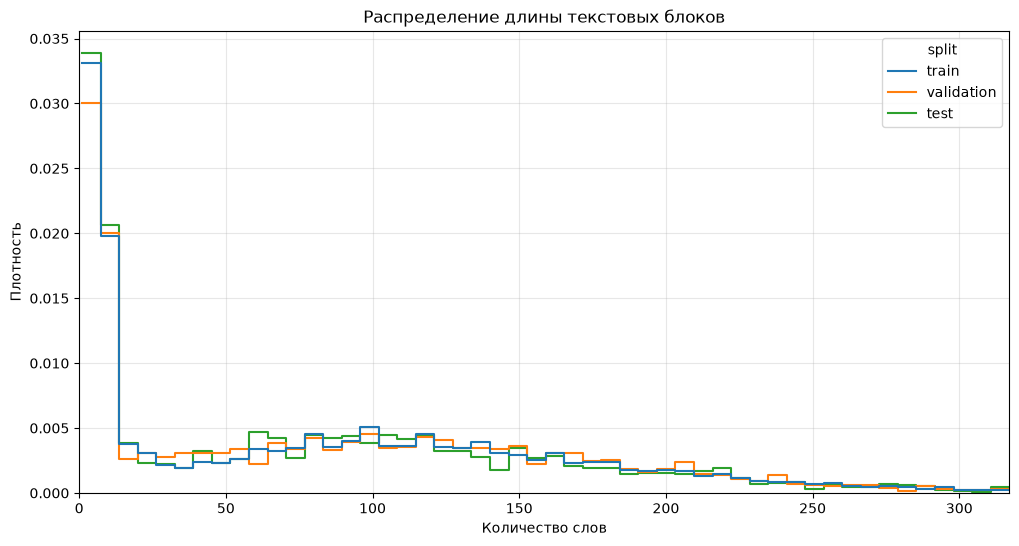

In [19]:
plot_limit = int(lengths_df["word_count"].quantile(0.99))

plt.figure(figsize=(12, 6))

sns.histplot(
    data=lengths_df[
        lengths_df["word_count"] <= plot_limit
    ],
    x="word_count",
    hue="split",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
)

plt.title("Распределение длины текстовых блоков")
plt.xlabel("Количество слов")
plt.ylabel("Плотность")
plt.xlim(0, plot_limit)
plt.grid(alpha=0.3)
plt.show()

Распределения во всех выборках почти совпадают. В данных много коротких блоков-заголовков и присутствует длинный хвост до 300 слов.

### Длина текстовых блоков

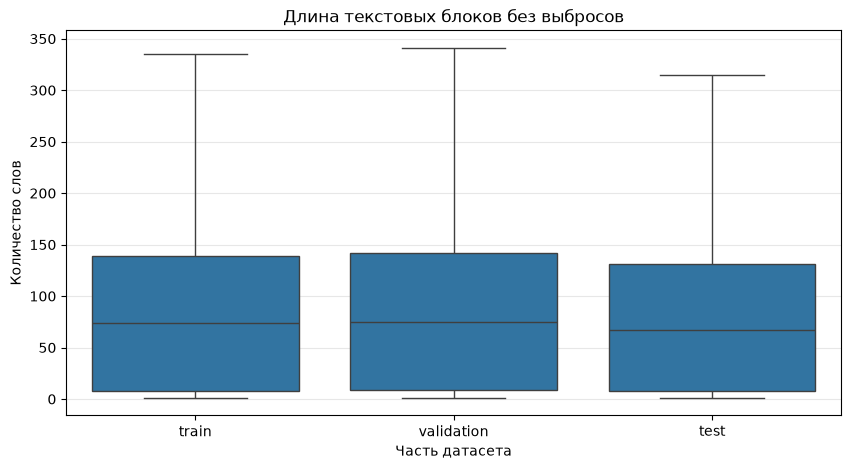

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=lengths_df,
    x="split",
    y="word_count",
    showfliers=False,
)

plt.title("Длина текстовых блоков без выбросов")
plt.xlabel("Часть датасета")
plt.ylabel("Количество слов")
plt.grid(axis="y", alpha=0.3)
plt.show()

Медианы и разброс длины текстов во всех частях датасета близки. Это означает, что `train`, `validation` и `test` имеют схожее распределение и подходят для корректного обучения и оценки моделей.

# 4. Предобработка данных

Перед очисткой проверим количество заголовков, предложений и специальных обозначений пунктуации. Это поможет определить необходимые правила предобработки текста.

In [ ]:


markup_statistics = []

for split_name in ["train", "validation", "test"]:
    texts = [
        text.strip()
        for text in dataset[split_name]["text"]
        if text.strip()
    ]

    headings = sum(
        text.startswith("=") and text.endswith("=")
        for text in texts
    )

    approximate_sentences = sum(
        len(re.findall(r"[.!?](?:\s|$)", text))
        for text in texts
    )

    full_text = " ".join(texts)

    markup_statistics.append(
        {
            "split": split_name,
            "headings": headings,
            "approximate_sentences": approximate_sentences,
            "hyphen_markers": full_text.count("@-@"),
            "comma_markers": full_text.count("@,@"),
            "period_markers": full_text.count("@.@"),
        }
    )

markup_df = pd.DataFrame(markup_statistics)
markup_df

,split,headings,approximate_sentences,hyphen_markers,comma_markers,period_markers
0,train,6211,78807,16906,2699,3194
1,validation,620,8439,1864,391,263
2,test,706,9410,2114,381,522


Во всех частях датасета встречается служебная разметка заголовков и специальные обозначения пунктуации. Перед токенизацией заменим `@-@`, `@,@` и `@.@` на обычные знаки, а из заголовков удалим символы `=`, сохранив их текст.

Количество предложений является приблизительным, поскольку рассчитано с помощью регулярного выражения. Распределение служебных элементов между выборками выглядит схожим.

In [23]:
markers = ["@-@", "@,@", "@.@"]

for marker in markers:
    examples = [
        text.strip()
        for text in dataset["train"]["text"]
        if marker in text
    ][:3]

    print(f"\nМаркер {marker!r}:")
    
    for example in examples:
        position = example.find(marker)
        start = max(0, position - 50)
        end = min(len(example), position + 50)

        print(example[start:end])


Маркер '@-@':
Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media
ames , Valkyria Chronicles III is a tactical role @-@ playing game where players take control of a m
g missions , players select each unit using a top @-@ down perspective of the battlefield map : once

Маркер '@,@':
es charts . By early February , the game sold 102 @,@ 779 units , coming in second overall to The La
t , supervised the construction . Originally $ 14 @,@ 000 was allocated for the construction of the 
 February 5 , six militia units , consisting of 1 @,@ 000 men , with a guarantee that the numbers co

Маркер '@.@':
ilding was designed with 3 @-@ foot @-@ thick ( 0 @.@ 91 m ) exterior walls . The original plans cal
orld Has Come was purchased by Queen Mary for ₤ 5 @.@ 5 @.@ 0 in 1926 . The Croydon Art Society hung
itats off northern Australia . Reaching 24 cm ( 9 @.@ 4 in ) in width , this species has a diamond @


Вывод

Просмотр примеров показал, что `@-@`, `@,@` и `@.@` обозначают дефис, запятую и точку внутри слов или чисел. Перед токенизацией заменим их на обычные символы без окружающих пробелов.

Создаём функцию очистки

In [26]:
def clean_text(text):
    """Очищает один текстовый блок WikiText-2."""

    text = text.strip()

    if not text:
        return ""

    # Восстанавливаем пунктуацию
    text = re.sub(r"\s*@-@\s*", "-", text)
    text = re.sub(r"\s*@,@\s*", ",", text)
    text = re.sub(r"\s*@\.@\s*", ".", text)

    # Убираем символы разметки заголовков по краям
    if text.startswith("=") and text.endswith("="):
        text = re.sub(r"^(?:=\s*)+", "", text)
        text = re.sub(r"(?:\s*=\s*)+$", "", text)

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text

Проверяем функцию на примерах

In [27]:
example_texts = [
    text
    for text in dataset["train"]["text"]
    if text.strip()
][:5]

for original_text in example_texts:
    print("До:   ", original_text[:200])
    print("После:", clean_text(original_text)[:200])
    print("-" * 80)

До:     = Valkyria Chronicles III = 

После: Valkyria Chronicles III
--------------------------------------------------------------------------------
До:     Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p
После: Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role-playin
--------------------------------------------------------------------------------
До:     The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adju
После: The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the stan

Очищаем все выборки

In [28]:
raw_dataset = dataset

cleaned_dataset = raw_dataset.map(
    lambda row: {"text": clean_text(row["text"])}
)

cleaned_dataset = cleaned_dataset.filter(
    lambda row: bool(row["text"])
)

Filter: 100%|██████████| 3760/3760 [00:00<00:00, 454706.43 examples/s]


Проверяем результат

In [29]:
for split_name in ["train", "validation", "test"]:
    texts = cleaned_dataset[split_name]["text"]
    full_text = " ".join(texts)

    print(f"{split_name}:")
    print(f"  текстов: {len(texts):,}")
    print(f"  пустых: {sum(not text.strip() for text in texts)}")
    print(
        "  оставшихся маркеров:",
        sum(full_text.count(marker) for marker in ["@-@", "@,@", "@.@"]),
    )

train:
  текстов: 23,767
  пустых: 0
  оставшихся маркеров: 0
validation:
  текстов: 2,461
  пустых: 0
  оставшихся маркеров: 0
test:
  текстов: 2,891
  пустых: 0
  оставшихся маркеров: 0


# 5. Создание выборок для быстрого запуска

Для отладки создадим уменьшенные версии обучающей, валидационной и тестовой выборок. Они позволят быстро проверить токенизацию, формирование последовательностей и обучение моделей.

При итоговом запуске `FAST_RUN` будет установлен в `False`, и модели будут обучены на полном датасете.

In [30]:
from datasets import DatasetDict

FAST_LIMITS = {
    "train": 2000,
    "validation": 300,
    "test": 300,
}

if FAST_RUN:
    working_dataset = DatasetDict(
        {
            split_name: (
                cleaned_dataset[split_name]
                .shuffle(seed=SEED)
                .select(
                    range(
                        min(
                            FAST_LIMITS[split_name],
                            len(cleaned_dataset[split_name]),
                        )
                    )
                )
            )
            for split_name in ["train", "validation", "test"]
        }
    )
else:
    working_dataset = cleaned_dataset

In [31]:
for split_name in ["train", "validation", "test"]:
    print(
        f"{split_name}: "
        f"{len(working_dataset[split_name]):,} текстов"
    )

train: 2,000 текстов
validation: 300 текстов
test: 300 текстов


Уменьшенные выборки используются только для проверки работоспособности кода. Финальные значения метрик будут рассчитаны после обучения на полном датасете. Обе рекуррентные модели будут использовать одинаковые выборки.

# 6. Пословная токенизация

Преобразуем каждый текстовый блок в последовательность токенов. Слова будут приведены к нижнему регистру, что уменьшит размер словаря. Знаки препинания будут сохранены как отдельные токены, поскольку они также важны для языковой модели.

### 6.1 Функция токенизации

In [32]:
TOKEN_PATTERN = re.compile(
    r"\w+(?:['’]\w+)*|['’]\w+|[^\w\s]",
    flags=re.UNICODE,
)


def tokenize(text):
    """Разбивает текст на слова и знаки препинания."""

    text = text.lower()
    return TOKEN_PATTERN.findall(text)

Проверка на примере

In [33]:
example = "The player's role-playing game costs 1,000 dollars."

print("Исходный текст:")
print(example)

print("\nТокены:")
print(tokenize(example))

Исходный текст:
The player's role-playing game costs 1,000 dollars.

Токены:
['the', "player's", 'role', '-', 'playing', 'game', 'costs', '1', ',', '000', 'dollars', '.']


Проверка на WikiText-2

In [34]:
sample_text = working_dataset["train"][0]["text"]
sample_tokens = tokenize(sample_text)

print("Текст:")
print(sample_text[:500])

print("\nПервые 50 токенов:")
print(sample_tokens[:50])

print(f"\nКоличество токенов: {len(sample_tokens)}")

Текст:
The ship 's primary armament consisted of four 30.5 cm ( 12 in ) 45-caliber guns in two twin gun turrets . This was augmented by a heavy secondary battery of eight 24 cm ( 9.4 in ) guns in four wing turrets . The tertiary battery consisted of twenty 10 cm L / 50 guns in casemated single mounts , four 47 mm ( 1.85 in ) L / 44 and one 47 mm L / 33 quick-firing guns . Furthermore , the ship 's boats were equipped with two 66 mm ( 2.6 in ) landing guns for operations shore . Three 45 cm ( 17.7 in ) 

Первые 50 токенов:
['the', 'ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns', 'in', 'two', 'twin', 'gun', 'turrets', '.', 'this', 'was', 'augmented', 'by', 'a', 'heavy', 'secondary', 'battery', 'of', 'eight', '24', 'cm', '(', '9', '.', '4', 'in', ')', 'guns', 'in', 'four', 'wing', 'turrets', '.']

Количество токенов: 140


Токенизатор приводит слова к нижнему регистру и отделяет пунктуацию. Это уменьшает размер словаря и позволяет модели предсказывать не только слова, но и знаки препинания.

### 6.2 Построение словаря

Словарь строится только по обучающей выборке, чтобы исключить утечку информации из `validation` и `test`.

Сначала подсчитаем частоты токенов и проверим несколько значений `min_freq`. Редкие токены будут заменяться на `<unk>`. Это уменьшит размер модели, поскольку размер выходного слоя напрямую зависит от количества токенов в словаре.

Подсчёт токенов

In [35]:
train_token_counts = Counter()

for text in tqdm(
    working_dataset["train"]["text"],
    desc="Подсчёт токенов",
):
    train_token_counts.update(tokenize(text))

total_train_tokens = sum(train_token_counts.values())
unique_train_tokens = len(train_token_counts)

print(f"Всего токенов: {total_train_tokens:,}")
print(f"Уникальных токенов: {unique_train_tokens:,}")

Подсчёт токенов: 100%|██████████| 2000/2000 [00:00<00:00, 11906.18it/s]

Всего токенов: 175,383
Уникальных токенов: 19,423


Самые частые токены

In [36]:
frequent_tokens_df = pd.DataFrame(
    train_token_counts.most_common(20),
    columns=["token", "frequency"],
)

frequent_tokens_df

,token,frequency
0,the,11307
1,",",8965
2,.,7355
3,of,4826
4,and,4322
5,in,3891
6,to,3373
7,a,3146
8,"""",2659
9,was,1792


Выбор min_freq

In [37]:
MIN_FREQ_CANDIDATES = [1, 2, 3, 5, 10]

vocabulary_statistics = []

for min_freq in MIN_FREQ_CANDIDATES:
    retained_tokens = {
        token
        for token, frequency in train_token_counts.items()
        if frequency >= min_freq
    }

    covered_occurrences = sum(
        frequency
        for token, frequency in train_token_counts.items()
        if frequency >= min_freq
    )

    vocabulary_statistics.append(
        {
            "min_freq": min_freq,
            "vocabulary_size": len(retained_tokens) + 2,
            "coverage_percent": (
                covered_occurrences / total_train_tokens * 100
            ),
            "unknown_percent": (
                100 - covered_occurrences / total_train_tokens * 100
            ),
        }
    )

vocabulary_statistics_df = pd.DataFrame(
    vocabulary_statistics
).round(3)

vocabulary_statistics_df

,min_freq,vocabulary_size,coverage_percent,unknown_percent
0,1,19425,100.000,0.000
1,2,9747,94.482,5.518
2,3,6767,91.084,8.916
3,5,4226,86.177,13.823
4,10,2097,78.267,21.733


#### Вывод

При `min_freq = 2` размер словаря уменьшается почти в два раза, а покрытие обучающего текста остаётся высоким — 94,5%. При более высоких порогах доля неизвестных токенов заметно увеличивается. Поэтому предварительно выбрано значение `min_freq = 2`.

Перед окончательным выбором проверим долю <unk> на validation и test:

In [38]:
MIN_FREQ = 2

known_tokens = {
    token
    for token, frequency in train_token_counts.items()
    if frequency >= MIN_FREQ
}

for split_name in ["validation", "test"]:
    split_tokens = [
        token
        for text in working_dataset[split_name]["text"]
        for token in tokenize(text)
    ]

    unknown_count = sum(
        token not in known_tokens
        for token in split_tokens
    )

    unknown_percent = unknown_count / len(split_tokens) * 100

    print(
        f"{split_name}: "
        f"{unknown_percent:.2f}% неизвестных токенов"
    )

validation: 11.83% неизвестных токенов
test: 11.91% неизвестных токенов


Доля неизвестных токенов на `validation` и `test` практически одинакова — около 12%, что говорит о схожести выборок. Высокое значение связано с использованием уменьшенной обучающей выборки в режиме `FAST_RUN`.

Для отладки оставим `min_freq = 2`. При итоговом запуске на полном `train` словарь и доля неизвестных токенов будут пересчитаны.

Следующий этап — окончательно построить словарь, присвоить токенам числовые индексы и закодировать весь текст.

### 6.3 Создание словаря

In [39]:
SPECIAL_TOKENS = ["<unk>", "<eos>"]

vocabulary_tokens = [
    token
    for token, frequency in sorted(
        train_token_counts.items(),
        key=lambda item: (-item[1], item[0]),
    )
    if frequency >= MIN_FREQ
]

id_to_token = SPECIAL_TOKENS + vocabulary_tokens

token_to_id = {
    token: token_id
    for token_id, token in enumerate(id_to_token)
}

UNK_ID = token_to_id["<unk>"]
EOS_ID = token_to_id["<eos>"]

VOCAB_SIZE = len(id_to_token)

print(f"Размер словаря: {VOCAB_SIZE:,}")
print(f"ID <unk>: {UNK_ID}")
print(f"ID <eos>: {EOS_ID}")

Размер словаря: 9,747
ID <unk>: 0
ID <eos>: 1


Кодирование и декодирование

In [40]:
def encode_text(text):
    """Преобразует текст в индексы и добавляет <eos>."""

    token_ids = [
        token_to_id.get(token, UNK_ID)
        for token in tokenize(text)
    ]

    return token_ids + [EOS_ID]


def decode_ids(token_ids):
    """Преобразует индексы обратно в токены."""

    return [
        id_to_token[token_id]
        for token_id in token_ids
    ]

Проверка

In [41]:
sample_text = working_dataset["train"][0]["text"]
sample_ids = encode_text(sample_text)

print("Исходный текст:")
print(sample_text[:300])

print("\nПервые индексы:")
print(sample_ids[:30])

print("\nОбратное преобразование:")
print(decode_ids(sample_ids[:30]))

Исходный текст:
The ship 's primary armament consisted of four 30.5 cm ( 12 in ) 45-caliber guns in two twin gun turrets . This was augmented by a heavy secondary battery of eight 24 cm ( 9.4 in ) guns in four wing turrets . The tertiary battery consisted of twenty 10 cm L / 50 guns in casemated single mounts , fou

Первые индексы:
[2, 620, 17, 1141, 2698, 1264, 5, 96, 293, 4, 110, 1037, 21, 273, 7, 22, 824, 12, 3135, 571, 7, 49, 2082, 478, 3011, 4, 34, 11, 0, 19]

Обратное преобразование:
['the', 'ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns', 'in', 'two', 'twin', 'gun', 'turrets', '.', 'this', 'was', '<unk>', 'by']


Создание потоков токенов

In [42]:
encoded_splits = {}

for split_name in ["train", "validation", "test"]:
    token_stream = []

    for text in tqdm(
        working_dataset[split_name]["text"],
        desc=f"Кодирование {split_name}",
    ):
        token_stream.extend(encode_text(text))

    encoded_splits[split_name] = torch.tensor(
        token_stream,
        dtype=torch.long,
    )

    print(
        f"{split_name}: "
        f"{len(encoded_splits[split_name]):,} токенов"
    )

Кодирование train: 100%|██████████| 2000/2000 [00:00<00:00, 11517.94it/s]


train: 177,383 токенов


Кодирование validation: 100%|██████████| 300/300 [00:00<00:00, 11105.15it/s]


validation: 27,508 токенов


Кодирование test: 100%|██████████| 300/300 [00:00<00:00, 10609.90it/s]

test: 24,514 токенов


Словарь построен только по обучающей выборке. Редкие и неизвестные токены заменяются на `<unk>`, а после каждого текстового блока добавляется `<eos>`. Все части датасета преобразованы в числовые последовательности.

# 7. Dataset и DataLoader

Следующий этап - создать Dataset и DataLoader с правильным сдвигом входа и таргета.

### 7.1 Dataset для языковой модели

In [43]:
class LanguageModelDataset(Dataset):
    def __init__(self, token_stream, seq_len):
        self.token_stream = token_stream
        self.seq_len = seq_len

        self.number_of_sequences = (
            len(token_stream) - 1
        ) // seq_len

    def __len__(self):
        return self.number_of_sequences

    def __getitem__(self, index):
        start = index * self.seq_len
        end = start + self.seq_len + 1

        sequence = self.token_stream[start:end]

        x = sequence[:-1]
        y = sequence[1:]

        return x, y

Создание наборов данных

In [44]:
SEQ_LEN = 64
BATCH_SIZE = 64

sequence_datasets = {
    split_name: LanguageModelDataset(
        encoded_splits[split_name],
        seq_len=SEQ_LEN,
    )
    for split_name in ["train", "validation", "test"]
}

for split_name, split_dataset in sequence_datasets.items():
    print(
        f"{split_name}: "
        f"{len(split_dataset):,} последовательностей"
    )

train: 2,771 последовательностей
validation: 429 последовательностей
test: 383 последовательностей


Поверка сдвига. В результате Y должен быть сдвинут относительно X на один токен:

In [45]:
x_example, y_example = sequence_datasets["train"][0]

print("X:")
print(decode_ids(x_example[:20].tolist()))

print("\nY:")
print(decode_ids(y_example[:20].tolist()))

assert torch.equal(
    x_example[1:],
    y_example[:-1],
), "X и Y сдвинуты неправильно"

print("\nСдвиг выполнен правильно")

X:
['the', 'ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns']

Y:
['ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns', 'in']

Сдвиг выполнен правильно


### 7.2 Создание DataLoader

In [46]:
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    sequence_datasets["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)

validation_loader = DataLoader(
    sequence_datasets["validation"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    sequence_datasets["test"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

Проверка одного батча

In [47]:
x_batch, y_batch = next(iter(train_loader))

print(f"Форма X: {x_batch.shape}")
print(f"Форма Y: {y_batch.shape}")
print(f"Тип данных: {x_batch.dtype}")

Форма X: torch.Size([64, 64])
Форма Y: torch.Size([64, 64])
Тип данных: torch.int64


Для каждого входа `X` сформирован таргет `Y`, сдвинутый на один токен. Таким образом, модель на каждой позиции будет предсказывать следующий токен. Перемешивание используется только для обучающей выборки.

# 8. Реализация LSTM и GRU

Обе модели будут иметь одинаковую структуру:

`Embedding → LSTM/GRU → Dropout → Linear`

Embedding преобразует индексы токенов в векторы. Рекуррентный слой обрабатывает последовательность, а линейный слой рассчитывает оценки для всех токенов словаря.

Для честного сравнения LSTM и GRU будут использовать одинаковые размеры слоёв и параметры обучения.

## 8.1 Класс модели

In [48]:
class RecurrentLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        rnn_type="LSTM",
        dropout=0.2,
    ):
        super().__init__()

        rnn_type = rnn_type.upper()

        if rnn_type not in {"LSTM", "GRU"}:
            raise ValueError("rnn_type должен быть LSTM или GRU")

        self.rnn_type = rnn_type

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
        )

        self.dropout = nn.Dropout(dropout)

        rnn_class = nn.LSTM if rnn_type == "LSTM" else nn.GRU

        self.rnn = rnn_class(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_dim,
            vocab_size,
        )

    def forward(self, x, hidden=None):
        embedded = self.dropout(
            self.embedding(x)
        )

        output, hidden = self.rnn(
            embedded,
            hidden,
        )

        logits = self.output_layer(
            self.dropout(output)
        )

        return logits, hidden

Класс `RecurrentLanguageModel` описывает общую архитектуру для LSTM и GRU.

- `Embedding` преобразует индексы токенов в числовые векторы.
- `LSTM` или `GRU` обрабатывает последовательность и учитывает предыдущий контекст.
- `Dropout` снижает риск переобучения.
- `Linear` рассчитывает оценки для всех токенов словаря.
- Метод `forward` выполняет прямой проход и возвращает `logits` для предсказания следующего токена.

Единый класс позволяет честно сравнить LSTM и GRU при одинаковых размерах слоёв и настройках.

Начальные параметры

In [49]:
MODEL_CONFIG = {
    "vocab_size": VOCAB_SIZE,
    "embedding_dim": 128,
    "hidden_dim": 256,
    "num_layers": 2,
    "dropout": 0.2,
}

Для первого эксперимента выбраны умеренные параметры модели:

- `vocab_size` — количество токенов в словаре;
- `embedding_dim = 128` — размер векторного представления токена;
- `hidden_dim = 256` — размер скрытого состояния;
- `num_layers = 2` — количество рекуррентных слоёв;
- `dropout = 0.2` — доля отключаемых нейронов для снижения переобучения.

Эти значения являются начальными и могут быть скорректированы по результатам валидации.

Создание моделей

In [50]:
set_seed(SEED)

lstm_model = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="LSTM",
).to(DEVICE)

set_seed(SEED)

gru_model = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="GRU",
).to(DEVICE)

Созданы две модели с одинаковыми настройками: LSTM и GRU. Перед созданием каждой модели фиксируется `SEED`, а затем модели переносятся на выбранное устройство.


Подсчёт параметров и размера

In [51]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def model_size_mb(model):
    return sum(
        parameter.numel() * parameter.element_size()
        for parameter in model.parameters()
    ) / 1024**2


Функции `count_parameters` и `model_size_mb` рассчитывают количество обучаемых параметров и примерный размер весов. Эти показатели нужны для сравнения сложности моделей и их пригодности для мобильного устройства.

In [52]:
model_information = pd.DataFrame(
    [
        {
            "model": "LSTM",
            "parameters": count_parameters(lstm_model),
            "size_mb": model_size_mb(lstm_model),
        },
        {
            "model": "GRU",
            "parameters": count_parameters(gru_model),
            "size_mb": model_size_mb(gru_model),
        },
    ]
).round(2)

model_information

,model,parameters,size_mb
0,LSTM,4674195,17.83
1,GRU,4443795,16.95


GRU содержит 4,44 млн параметров и занимает около 16,95 МБ, а LSTM - 4,67 млн параметров и 17,83 МБ. GRU компактнее примерно на 5%, поскольку использует меньше внутренних управляющих механизмов.

Разница невелика, так как значительную часть параметров обеих моделей занимают одинаковые слои `Embedding` и `Linear`. Окончательный выбор будет сделан после сравнения качества и скорости.

Проверка прямого прохода

In [53]:
x_batch, _ = next(iter(train_loader))
x_batch = x_batch.to(DEVICE)

for model_name, model in [
    ("LSTM", lstm_model),
    ("GRU", gru_model),
]:
    model.eval()

    with torch.no_grad():
        logits, hidden = model(x_batch)

    print(
        f"{model_name}: "
        f"logits {tuple(logits.shape)}"
    )

    assert logits.shape == (
        x_batch.shape[0],
        x_batch.shape[1],
        VOCAB_SIZE,
    )

LSTM: logits (64, 64, 9747)
GRU: logits (64, 64, 9747)


Прямой проход обеих моделей выполняется корректно. Размер выхода `(64, 64, 9747)` означает:

- 64 последовательности в батче;
- 64 позиции в каждой последовательности;
- 9747 оценок токенов словаря для каждой позиции.

Следовательно, LSTM и GRU готовы к обучению.

## 8.2 Общий цикл обучения и оценки

Функция одной эпохи обучения

In [54]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    clip_value=1.0,
):
    model.train()

    total_loss = 0.0
    total_tokens = 0

    start_time = time.perf_counter()

    for x_batch, y_batch in tqdm(
        data_loader,
        desc="Обучение",
        leave=False,
    ):
        x_batch = x_batch.to(
            DEVICE,
            non_blocking=True,
        )
        y_batch = y_batch.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        logits, _ = model(x_batch)

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            y_batch.reshape(-1),
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=clip_value,
        )

        optimizer.step()

        number_of_tokens = y_batch.numel()

        total_loss += loss.item() * number_of_tokens
        total_tokens += number_of_tokens

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    epoch_time = time.perf_counter() - start_time
    average_loss = total_loss / total_tokens
    perplexity = math.exp(average_loss)

    return average_loss, perplexity, epoch_time

Функция оценки

In [55]:
@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    criterion,
):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(
            DEVICE,
            non_blocking=True,
        )
        y_batch = y_batch.to(
            DEVICE,
            non_blocking=True,
        )

        logits, _ = model(x_batch)

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            y_batch.reshape(-1),
        )

        number_of_tokens = y_batch.numel()

        total_loss += loss.item() * number_of_tokens
        total_tokens += number_of_tokens

    average_loss = total_loss / total_tokens
    perplexity = math.exp(average_loss)

    return average_loss, perplexity

Полный цикл обучения

In [ ]:



def fit_model(
    model,
    train_loader,
    validation_loader,
    epochs,
    learning_rate=0.001,
    clip_value=1.0,
    patience=3,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = []
    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_ppl, epoch_time = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            clip_value,
        )

        validation_loss, validation_ppl = evaluate_model(
            model,
            validation_loader,
            criterion,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_perplexity": train_ppl,
                "validation_loss": validation_loss,
                "validation_perplexity": validation_ppl,
                "epoch_time": epoch_time,
            }
        )

        print(
            f"Эпоха {epoch:02d} | "
            f"train loss: {train_loss:.4f} | "
            f"train PPL: {train_ppl:.2f} | "
            f"val loss: {validation_loss:.4f} | "
            f"val PPL: {validation_ppl:.2f} | "
            f"время: {epoch_time:.1f} сек."
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Ранняя остановка")
            break

    model.load_state_dict(best_state)

    return pd.DataFrame(history)

Настройки обучения

In [57]:
TRAIN_CONFIG = {
    "epochs": 3 if FAST_RUN else 10,
    "learning_rate": 0.001,
    "clip_value": 1.0,
    "patience": 3,
}

Параметры обучения означают:
- epochs - сколько раз модель проходит данные;
- learning_rate - скорость изменения весов;
- clip_value - защита от слишком больших градиентов;
- patience - сколько эпох ждать улучшения перед остановкой.

Цикл обучения рассчитывает loss и perplexity, применяет gradient clipping и измеряет время каждой эпохи. После обучения восстанавливаются веса с минимальным validation loss. Ранняя остановка предотвращает лишнее обучение при отсутствии улучшений.

#	9. Обучение LSTM и GRU на 8 % данных

In [68]:
for split_name in ["train", "validation", "test"]:
    used = len(working_dataset[split_name])
    full = len(cleaned_dataset[split_name])

    print(
        f"{split_name}: {used:,} из {full:,} "
        f"({used / full * 100:.1f}%)"
    )

train: 2,000 из 23,767 (8.4%)
validation: 300 из 2,461 (12.2%)
test: 300 из 2,891 (10.4%)


Сначала обучим LSTM в режиме `FAST_RUN`. Цель этого запуска - проверить, что loss и perplexity уменьшаются и цикл обучения работает корректно.

Запуск обучения

In [58]:
# Создаём новую необученную LSTM
set_seed(SEED)

lstm_model = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="LSTM",
).to(DEVICE)

# Фиксируем порядок батчей
train_loader.generator.manual_seed(SEED)

lstm_history = fit_model(
    model=lstm_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    **TRAIN_CONFIG,
)

Эпоха 01 | train loss: 7.3076 | train PPL: 1491.64 | val loss: 6.1854 | val PPL: 485.60 | время: 2.2 сек.


Эпоха 02 | train loss: 6.6572 | train PPL: 778.36 | val loss: 6.1413 | val PPL: 464.64 | время: 1.1 сек.


Эпоха 03 | train loss: 6.6334 | train PPL: 760.08 | val loss: 6.1261 | val PPL: 457.63 | время: 1.1 сек.


Результаты по эпохам

In [59]:
lstm_history.round(3)

,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,epoch_time
0,1,7.308,1491.641,6.185,485.601,2.231
1,2,6.657,778.363,6.141,464.640,1.107
2,3,6.633,760.082,6.126,457.628,1.089


За три эпохи train и validation loss уменьшились. Validation perplexity снизилась с 485,6 до 457,6, поэтому модель успешно обучается. Результаты пока предварительные, поскольку используется уменьшенная выборка.

In [60]:
set_seed(SEED)

gru_model = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="GRU",
).to(DEVICE)

# Возвращаем одинаковый порядок батчей
train_loader.generator.manual_seed(SEED)

gru_history = fit_model(
    model=gru_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    **TRAIN_CONFIG,
)

Эпоха 01 | train loss: 7.2374 | train PPL: 1390.52 | val loss: 6.1607 | val PPL: 473.75 | время: 1.2 сек.


Эпоха 02 | train loss: 6.6552 | train PPL: 776.84 | val loss: 6.1273 | val PPL: 458.21 | время: 1.2 сек.


Эпоха 03 | train loss: 6.6270 | train PPL: 755.24 | val loss: 6.1039 | val PPL: 447.60 | время: 1.2 сек.


In [61]:
gru_history.round(3)

,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,epoch_time
0,1,7.237,1390.521,6.161,473.752,1.168
1,2,6.655,776.839,6.127,458.210,1.234
2,3,6.627,755.240,6.104,447.603,1.219


Обе модели успешно обучаются. На уменьшенной выборке GRU показала validation perplexity 447,6, что примерно на 2% лучше результата LSTM - 457,6. Результат предварительный и будет перепроверен на полном датасете.

Теперь оцениваем обе модели на test:

In [65]:
criterion = nn.CrossEntropyLoss()

lstm_test_loss, lstm_test_ppl = evaluate_model(
    lstm_model,
    test_loader,
    criterion,
)

gru_test_loss, gru_test_ppl = evaluate_model(
    gru_model,
    test_loader,
    criterion,
)

Создаём таблицу сравнения:

In [66]:
rnn_comparison = pd.DataFrame(
    [
        {
            "model": "LSTM",
            "parameters": count_parameters(lstm_model),
            "size_mb": model_size_mb(lstm_model),
            "best_val_ppl": lstm_history[
                "validation_perplexity"
            ].min(),
            "test_ppl": lstm_test_ppl,
            "median_epoch_time": lstm_history[
                "epoch_time"
            ].median(),
        },
        {
            "model": "GRU",
            "parameters": count_parameters(gru_model),
            "size_mb": model_size_mb(gru_model),
            "best_val_ppl": gru_history[
                "validation_perplexity"
            ].min(),
            "test_ppl": gru_test_ppl,
            "median_epoch_time": gru_history[
                "epoch_time"
            ].median(),
        },
    ]
).round(2)

rnn_comparison

,model,parameters,size_mb,best_val_ppl,test_ppl,median_epoch_time
0,LSTM,4674195,17.83,457.63,454.67,1.11
1,GRU,4443795,16.95,447.60,444.82,1.22


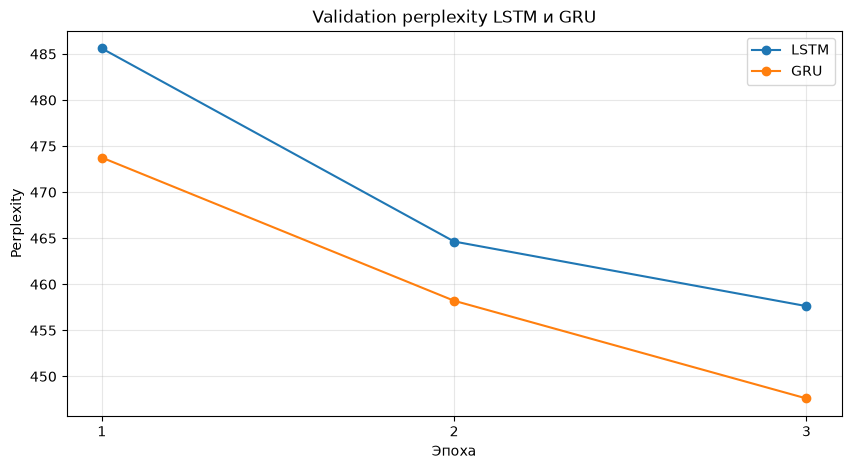

In [67]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history["epoch"],
    lstm_history["validation_perplexity"],
    marker="o",
    label="LSTM",
)

plt.plot(
    gru_history["epoch"],
    gru_history["validation_perplexity"],
    marker="o",
    label="GRU",
)

plt.title("Validation perplexity LSTM и GRU")
plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.xticks(lstm_history["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Perplexity обеих моделей снижается, значит обучение проходит успешно. На всех трёх эпохах GRU показывает немного лучший результат, чем LSTM. Вывод предварительный, поскольку модели обучались на уменьшенной выборке.

Дальше подберем длинну последовательности seq_len, как мы планировали. Проверим 16, 32, 64 и 128 на GRU в быстром режиме.

## 9.2 Создание DataLoader для разной длины

In [69]:
def create_loaders_for_seq_len(seq_len):
    train_dataset = LanguageModelDataset(
        encoded_splits["train"],
        seq_len,
    )

    validation_dataset = LanguageModelDataset(
        encoded_splits["validation"],
        seq_len,
    )

    generator = torch.Generator().manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, validation_loader

Сравнение

In [70]:
SEQ_LENGTH_CANDIDATES = [16, 32, 64, 128]
seq_len_results = []

for seq_len in SEQ_LENGTH_CANDIDATES:
    print(f"\nПроверка seq_len = {seq_len}")

    current_train_loader, current_validation_loader = (
        create_loaders_for_seq_len(seq_len)
    )

    set_seed(SEED)

    current_model = RecurrentLanguageModel(
        **MODEL_CONFIG,
        rnn_type="GRU",
    ).to(DEVICE)

    current_history = fit_model(
        model=current_model,
        train_loader=current_train_loader,
        validation_loader=current_validation_loader,
        epochs=2,
        learning_rate=0.001,
        clip_value=1.0,
        patience=2,
    )

    seq_len_results.append(
        {
            "seq_len": seq_len,
            "validation_perplexity": current_history[
                "validation_perplexity"
            ].min(),
            "median_epoch_time": current_history[
                "epoch_time"
            ].median(),
        }
    )

    del current_model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


Проверка seq_len = 16


Эпоха 01 | train loss: 6.9568 | train PPL: 1050.30 | val loss: 6.1156 | val PPL: 452.89 | время: 1.7 сек.


Эпоха 02 | train loss: 6.5722 | train PPL: 714.94 | val loss: 5.9756 | val PPL: 393.69 | время: 1.7 сек.

Проверка seq_len = 32


Эпоха 01 | train loss: 7.0500 | train PPL: 1152.86 | val loss: 6.1557 | val PPL: 471.40 | время: 1.3 сек.


Эпоха 02 | train loss: 6.6572 | train PPL: 778.39 | val loss: 6.0996 | val PPL: 445.67 | время: 1.3 сек.

Проверка seq_len = 64


Эпоха 01 | train loss: 7.2374 | train PPL: 1390.52 | val loss: 6.1607 | val PPL: 473.75 | время: 1.2 сек.


Эпоха 02 | train loss: 6.6552 | train PPL: 776.84 | val loss: 6.1273 | val PPL: 458.21 | время: 1.2 сек.

Проверка seq_len = 128


Эпоха 01 | train loss: 7.6415 | train PPL: 2082.90 | val loss: 6.1647 | val PPL: 475.66 | время: 1.0 сек.


Эпоха 02 | train loss: 6.6685 | train PPL: 787.25 | val loss: 6.1201 | val PPL: 454.92 | время: 1.0 сек.


По этой таблице выберем длину с хорошей perplexity без чрезмерного увеличения времени. После выбора перейдём к полному обучению.

In [71]:
seq_len_results_df = (
    pd.DataFrame(seq_len_results)
    .sort_values("validation_perplexity")
    .round(2)
)

seq_len_results_df

,seq_len,validation_perplexity,median_epoch_time
0,16,393.69,1.73
1,32,445.67,1.28
3,128,454.92,1.02
2,64,458.21,1.19


Таблица показывает лучший результат у seq_len=16, но сравнение получилось не совсем честным: при одинаковом batch_size=64 короткая последовательность получает больше обновлений весов за эпоху.
Нужно сохранить одинаковое количество токенов в батче:

In [72]:
TOKENS_PER_BATCH = 4096


def create_loaders_for_seq_len(seq_len):
    batch_size = TOKENS_PER_BATCH // seq_len

    train_dataset = LanguageModelDataset(
        encoded_splits["train"],
        seq_len,
    )

    validation_dataset = LanguageModelDataset(
        encoded_splits["validation"],
        seq_len,
    )

    generator = torch.Generator().manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, validation_loader, batch_size

Повторяем эксперимент:

In [73]:
seq_len_results = []

for seq_len in [16, 32, 64, 128]:
    (
        current_train_loader,
        current_validation_loader,
        current_batch_size,
    ) = create_loaders_for_seq_len(seq_len)

    print(
        f"\nseq_len={seq_len}, "
        f"batch_size={current_batch_size}"
    )

    set_seed(SEED)

    current_model = RecurrentLanguageModel(
        **MODEL_CONFIG,
        rnn_type="GRU",
    ).to(DEVICE)

    current_history = fit_model(
        current_model,
        current_train_loader,
        current_validation_loader,
        epochs=2,
        learning_rate=0.001,
        clip_value=1.0,
        patience=2,
    )

    seq_len_results.append(
        {
            "seq_len": seq_len,
            "batch_size": current_batch_size,
            "validation_perplexity": current_history[
                "validation_perplexity"
            ].min(),
            "median_epoch_time": current_history[
                "epoch_time"
            ].median(),
        }
    )

    del current_model
    torch.cuda.empty_cache()


seq_len=16, batch_size=256


Эпоха 01 | train loss: 7.3409 | train PPL: 1542.03 | val loss: 6.2095 | val PPL: 497.45 | время: 1.0 сек.


Эпоха 02 | train loss: 6.6839 | train PPL: 799.46 | val loss: 6.1473 | val PPL: 467.46 | время: 0.9 сек.

seq_len=32, batch_size=128


Эпоха 01 | train loss: 7.2721 | train PPL: 1439.55 | val loss: 6.1737 | val PPL: 479.96 | время: 1.0 сек.


Эпоха 02 | train loss: 6.6652 | train PPL: 784.64 | val loss: 6.1357 | val PPL: 462.06 | время: 1.1 сек.

seq_len=64, batch_size=64


Эпоха 01 | train loss: 7.2374 | train PPL: 1390.52 | val loss: 6.1607 | val PPL: 473.75 | время: 1.2 сек.


Эпоха 02 | train loss: 6.6552 | train PPL: 776.84 | val loss: 6.1273 | val PPL: 458.21 | время: 1.3 сек.

seq_len=128, batch_size=32


Эпоха 01 | train loss: 7.2212 | train PPL: 1368.10 | val loss: 6.1339 | val PPL: 461.21 | время: 1.6 сек.


Эпоха 02 | train loss: 6.6474 | train PPL: 770.79 | val loss: 6.1037 | val PPL: 447.50 | время: 1.6 сек.


Теперь каждый батч содержит примерно 4096 токенов, поэтому сравнение будет корректнее. Предыдущую таблицу для выбора seq_len не используем.

In [74]:
seq_len_results_df = (
    pd.DataFrame(seq_len_results)
    .sort_values("validation_perplexity")
    .round(2)
)

seq_len_results_df

,seq_len,batch_size,validation_perplexity,median_epoch_time
3,128,32,447.50,1.60
2,64,64,458.21,1.26
1,32,128,462.06,1.06
0,16,256,467.46,0.93


Наименьшую perplexity показал `seq_len = 128`, но он обучается заметно дольше. Значение `64` даёт perplexity всего примерно на 2,4% хуже.

С учётом ограничений мобильного устройства выбираем `seq_len = 64` как лучший баланс качества и скорости. При seq_len=64 модель обрабатывает вдвое меньше токенов, чем при 128, поэтому потенциально работает быстрее и использует меньше оперативной памяти.

# 10. Обучение на полном объеме данных

## 10.1 Подготовка полного датасета и выбор `min_freq`

После проверки pipeline на уменьшенной выборке переходим к полному датасету. Повторно подсчитаем частоты токенов и выберем окончательный порог `min_freq`, который определяет размер словаря и долю неизвестных слов.

In [76]:
# Переходим от тестового режима к полному датасету
FAST_RUN = False
working_dataset = cleaned_dataset

print("Размеры полного датасета:")

for split_name in ["train", "validation", "test"]:
    print(
        f"{split_name}: "
        f"{len(working_dataset[split_name]):,} текстов"
    )


# Заново считаем частоты токенов по полному train
train_token_counts = Counter()

for text in tqdm(
    working_dataset["train"]["text"],
    desc="Подсчёт токенов полного train",
):
    train_token_counts.update(tokenize(text))

total_train_tokens = sum(train_token_counts.values())
unique_train_tokens = len(train_token_counts)

print(f"\nВсего токенов: {total_train_tokens:,}")
print(f"Уникальных токенов: {unique_train_tokens:,}")


# Сравниваем пороги включения токенов в словарь
MIN_FREQ_CANDIDATES = [1, 2, 3, 5, 10]
vocabulary_statistics = []

for min_freq in MIN_FREQ_CANDIDATES:
    vocabulary_size = sum(
        frequency >= min_freq
        for frequency in train_token_counts.values()
    )

    covered_tokens = sum(
        frequency
        for frequency in train_token_counts.values()
        if frequency >= min_freq
    )

    coverage_percent = (
        covered_tokens / total_train_tokens * 100
    )

    vocabulary_statistics.append(
        {
            "min_freq": min_freq,
            # <unk> и <eos>
            "vocabulary_size": vocabulary_size + 2,
            "coverage_percent": coverage_percent,
            "unknown_percent": 100 - coverage_percent,
        }
    )

vocabulary_statistics_df = pd.DataFrame(
    vocabulary_statistics
).round(3)

vocabulary_statistics_df

Размеры полного датасета:
train: 23,767 текстов
validation: 2,461 текстов
test: 2,891 текстов


Подсчёт токенов полного train: 100%|██████████| 23767/23767 [00:01<00:00, 14094.06it/s]


Всего токенов: 2,031,220
Уникальных токенов: 66,081


,min_freq,vocabulary_size,coverage_percent,unknown_percent
0,1,66083,100.000,0.000
1,2,39191,98.676,1.324
2,3,29506,97.722,2.278
3,5,20946,96.292,3.708
4,10,13182,93.782,6.218


## 10.2 Построение итогового словаря и кодирование полного датасета

На основе анализа выбран порог `min_freq = 3`. Построим итоговый словарь только по обучающей выборке, присвоим токенам числовые индексы и закодируем полные выборки `train`, `validation` и `test`.

In [77]:
MIN_FREQ = 3
SPECIAL_TOKENS = ["<unk>", "<eos>"]

# Сортируем для воспроизводимости словаря
vocabulary_tokens = [
    token
    for token, frequency in sorted(
        train_token_counts.items(),
        key=lambda item: (-item[1], item[0]),
    )
    if frequency >= MIN_FREQ
]

id_to_token = SPECIAL_TOKENS + vocabulary_tokens

token_to_id = {
    token: token_id
    for token_id, token in enumerate(id_to_token)
}

UNK_ID = token_to_id["<unk>"]
EOS_ID = token_to_id["<eos>"]
VOCAB_SIZE = len(id_to_token)

print(f"Размер итогового словаря: {VOCAB_SIZE:,}")


def encode_text(text):
    token_ids = [
        token_to_id.get(token, UNK_ID)
        for token in tokenize(text)
    ]

    return token_ids + [EOS_ID]


def decode_ids(token_ids):
    return [
        id_to_token[token_id]
        for token_id in token_ids
    ]


# Кодируем полный train, validation и test
encoded_splits = {}

for split_name in ["train", "validation", "test"]:
    token_stream = []

    for text in tqdm(
        working_dataset[split_name]["text"],
        desc=f"Кодирование {split_name}",
    ):
        token_stream.extend(encode_text(text))

    encoded_splits[split_name] = torch.tensor(
        token_stream,
        dtype=torch.long,
    )

    text_token_count = (
        len(token_stream)
        - len(working_dataset[split_name])
    )

    unknown_count = int(
        (encoded_splits[split_name] == UNK_ID)
        .sum()
        .item()
    )

    unknown_percent = (
        unknown_count / text_token_count * 100
    )

    print(
        f"{split_name}: "
        f"{len(token_stream):,} токенов, "
        f"<unk>: {unknown_percent:.2f}%"
    )

Размер итогового словаря: 29,506


Кодирование train: 100%|██████████| 23767/23767 [00:01<00:00, 12665.35it/s]


train: 2,054,987 токенов, <unk>: 2.28%


Кодирование validation: 100%|██████████| 2461/2461 [00:00<00:00, 10634.30it/s]


validation: 214,507 токенов, <unk>: 4.79%


Кодирование test: 100%|██████████| 2891/2891 [00:00<00:00, 11525.62it/s]

test: 241,504 токенов, <unk>: 5.71%


- каждому слову присвоили числовой ID;
- редкие слова заменили на <unk>;
- после каждого текстового блока добавили <eos>;
- получили итоговый словарь из 29 506 токенов.
Доля <unk> составляет 2,28% на train и около 5% на validation/test. Это нормально: в новых текстах встречаются слова, которых модель не видела достаточно часто.
Теперь делим числовой поток на последовательности длиной 64 и создаём полные DataLoader:

## 10.3 Формирование последовательностей и DataLoader для полного датасета

In [78]:
SEQ_LEN = 64
BATCH_SIZE = 64

sequence_datasets = {
    split_name: LanguageModelDataset(
        encoded_splits[split_name],
        seq_len=SEQ_LEN,
    )
    for split_name in ["train", "validation", "test"]
}

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    sequence_datasets["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)

validation_loader = DataLoader(
    sequence_datasets["validation"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    sequence_datasets["test"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

for split_name, split_dataset in sequence_datasets.items():
    print(
        f"{split_name}: "
        f"{len(split_dataset):,} последовательностей"
    )

print(f"\nОбучающих батчей: {len(train_loader):,}")

train: 32,109 последовательностей
validation: 3,351 последовательностей
test: 3,773 последовательностей

Обучающих батчей: 502


Обновляем конфигурацию модели под новый словарь:

In [79]:
MODEL_CONFIG = {
    "vocab_size": VOCAB_SIZE,
    "embedding_dim": 128,
    "hidden_dim": 256,
    "num_layers": 2,
    "dropout": 0.2,
}

print(f"Размер словаря модели: {MODEL_CONFIG['vocab_size']:,}")

Размер словаря модели: 29,506


## 10.4 Полное обучение LSTM

Создание модели

In [80]:
set_seed(SEED)

lstm_model = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="LSTM",
).to(DEVICE)

print(
    f"Параметров LSTM: "
    f"{count_parameters(lstm_model):,}"
)

print(
    f"Размер весов: "
    f"{model_size_mb(lstm_model):.2f} МБ"
)

Параметров LSTM: 12,281,410
Размер весов: 46.85 МБ


Настройки полного обучения

In [81]:
FULL_TRAIN_CONFIG = {
    "epochs": 10,
    "learning_rate": 0.001,
    "clip_value": 1.0,
    "patience": 2,
}

Запуск

In [82]:
train_loader.generator.manual_seed(SEED)

lstm_history = fit_model(
    model=lstm_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    **FULL_TRAIN_CONFIG,
)

Эпоха 01 | train loss: 7.1574 | train PPL: 1283.51 | val loss: 6.7363 | val PPL: 842.48 | время: 25.0 сек.


Эпоха 02 | train loss: 6.7351 | train PPL: 841.44 | val loss: 6.3167 | val PPL: 553.76 | время: 24.9 сек.


Эпоха 03 | train loss: 6.4451 | train PPL: 629.61 | val loss: 6.1146 | val PPL: 452.40 | время: 24.1 сек.


Эпоха 04 | train loss: 6.2762 | train PPL: 531.76 | val loss: 5.9874 | val PPL: 398.40 | время: 23.9 сек.


Эпоха 05 | train loss: 6.1571 | train PPL: 472.08 | val loss: 5.9025 | val PPL: 365.94 | время: 23.7 сек.


Эпоха 06 | train loss: 6.0538 | train PPL: 425.72 | val loss: 5.8167 | val PPL: 335.85 | время: 24.1 сек.


Эпоха 07 | train loss: 5.9455 | train PPL: 382.04 | val loss: 5.7299 | val PPL: 307.93 | время: 23.7 сек.


Эпоха 08 | train loss: 5.8331 | train PPL: 341.42 | val loss: 5.6443 | val PPL: 282.68 | время: 23.7 сек.


Эпоха 09 | train loss: 5.7260 | train PPL: 306.74 | val loss: 5.5722 | val PPL: 263.02 | время: 24.2 сек.


Эпоха 10 | train loss: 5.6259 | train PPL: 277.51 | val loss: 5.5050 | val PPL: 245.91 | время: 23.7 сек.


Сохранение лучшей модели

In [83]:
from pathlib import Path

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

torch.save(
    lstm_model.state_dict(),
    CHECKPOINT_DIR / "best_lstm.pt",
)

lstm_history.round(3)

,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,epoch_time
0,1,7.157,1283.508,6.736,842.479,24.963
1,2,6.735,841.436,6.317,553.757,24.881
2,3,6.445,629.609,6.115,452.398,24.122
3,4,6.276,531.763,5.987,398.396,23.933
4,5,6.157,472.078,5.902,365.937,23.738
5,6,6.054,425.717,5.817,335.853,24.107
6,7,5.946,382.039,5.730,307.934,23.698
7,8,5.833,341.424,5.644,282.681,23.706
8,9,5.726,306.738,5.572,263.020,24.225
9,10,5.626,277.512,5.505,245.913,23.652


### Вывод по обучению LSTM

На протяжении десяти эпох train и validation perplexity стабильно снижались. Лучшая validation perplexity составила 245,9. Признаков переобучения не обнаружено.

## 10.5 Полное обучение GRU

Теперь обучаем GRU в точно таких же условиях.

In [85]:
set_seed(SEED)

gru_model = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="GRU",
).to(DEVICE)

print(
    f"Параметров GRU: "
    f"{count_parameters(gru_model):,}"
)

print(
    f"Размер весов: "
    f"{model_size_mb(gru_model):.2f} МБ"
)

train_loader.generator.manual_seed(SEED)

gru_history = fit_model(
    model=gru_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    **FULL_TRAIN_CONFIG,
)

torch.save(
    gru_model.state_dict(),
    CHECKPOINT_DIR / "best_gru.pt",
)

gru_history.round(3)

Параметров GRU: 12,051,010
Размер весов: 45.97 МБ


Эпоха 01 | train loss: 7.0839 | train PPL: 1192.67 | val loss: 6.5703 | val PPL: 713.58 | время: 25.0 сек.


Эпоха 02 | train loss: 6.7148 | train PPL: 824.55 | val loss: 6.3330 | val PPL: 562.82 | время: 25.2 сек.


Эпоха 03 | train loss: 6.4376 | train PPL: 624.91 | val loss: 6.0254 | val PPL: 413.82 | время: 26.1 сек.


Эпоха 04 | train loss: 6.1736 | train PPL: 479.90 | val loss: 5.8204 | val PPL: 337.09 | время: 25.9 сек.


...

Эпоха 07 | train loss: 5.6260 | train PPL: 277.56 | val loss: 5.4481 | val PPL: 232.31 | время: 24.0 сек.


Эпоха 08 | train loss: 5.4860 | train PPL: 241.30 | val loss: 5.3806 | val PPL: 217.15 | время: 24.7 сек.


Эпоха 09 | train loss: 5.3695 | train PPL: 214.75 | val loss: 5.3245 | val PPL: 205.31 | время: 24.1 сек.


Эпоха 10 | train loss: 5.2677 | train PPL: 193.97 | val loss: 5.2876 | val PPL: 197.87 | время: 24.1 сек.


,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,epoch_time
0,1,7.084,1192.666,6.570,713.575,25.026
1,2,6.715,824.553,6.333,562.819,25.152
2,3,6.438,624.905,6.025,413.819,26.141
3,4,6.174,479.896,5.820,337.092,25.945
4,5,5.968,390.900,5.666,288.869,26.172
5,6,5.788,326.214,5.544,255.667,25.758
6,7,5.626,277.563,5.448,232.315,24.046
7,8,5.486,241.300,5.381,217.151,24.673
8,9,5.369,214.745,5.325,205.308,24.123
9,10,5.268,193.973,5.288,197.869,24.129


### Вывод по обучению GRU

За десять эпох validation perplexity GRU снизилась с 713,6 до 197,9. Это лучше результата LSTM, у которой итоговая validation perplexity составила 245,9. Обе модели обучались одинаковое количество эпох на одних данных.

Теперь рассчитываем финальную perplexity на test:

In [86]:
criterion = nn.CrossEntropyLoss()

lstm_test_loss, lstm_test_ppl = evaluate_model(
    lstm_model,
    test_loader,
    criterion,
)

gru_test_loss, gru_test_ppl = evaluate_model(
    gru_model,
    test_loader,
    criterion,
)

print(
    f"LSTM test loss: {lstm_test_loss:.4f}, "
    f"test PPL: {lstm_test_ppl:.2f}"
)

print(
    f"GRU test loss: {gru_test_loss:.4f}, "
    f"test PPL: {gru_test_ppl:.2f}"
)

LSTM test loss: 5.4466, test PPL: 231.97
GRU test loss: 5.2186, test PPL: 184.68


Затем создаём итоговую таблицу рекуррентных моделей:

In [87]:
rnn_comparison = pd.DataFrame(
    [
        {
            "model": "LSTM",
            "parameters": count_parameters(lstm_model),
            "size_mb": model_size_mb(lstm_model),
            "best_val_ppl": lstm_history[
                "validation_perplexity"
            ].min(),
            "test_ppl": lstm_test_ppl,
            "median_epoch_time": lstm_history[
                "epoch_time"
            ].median(),
        },
        {
            "model": "GRU",
            "parameters": count_parameters(gru_model),
            "size_mb": model_size_mb(gru_model),
            "best_val_ppl": gru_history[
                "validation_perplexity"
            ].min(),
            "test_ppl": gru_test_ppl,
            "median_epoch_time": gru_history[
                "epoch_time"
            ].median(),
        },
    ]
).round(2)

rnn_comparison

,model,parameters,size_mb,best_val_ppl,test_ppl,median_epoch_time
0,LSTM,12281410,46.85,245.91,231.97,24.02
1,GRU,12051010,45.97,197.87,184.68,25.09


### Вывод по сравнению LSTM и GRU

GRU показала лучшее качество: test perplexity составила 184,68 против 231,97 у LSTM. GRU также содержит меньше параметров и занимает на 0,88 МБ меньше. Время эпохи оказалось немного выше, поэтому главное преимущество GRU в данном эксперименте — более высокая точность при немного меньшем размере.

Теперь строим финальный график полного обучения:

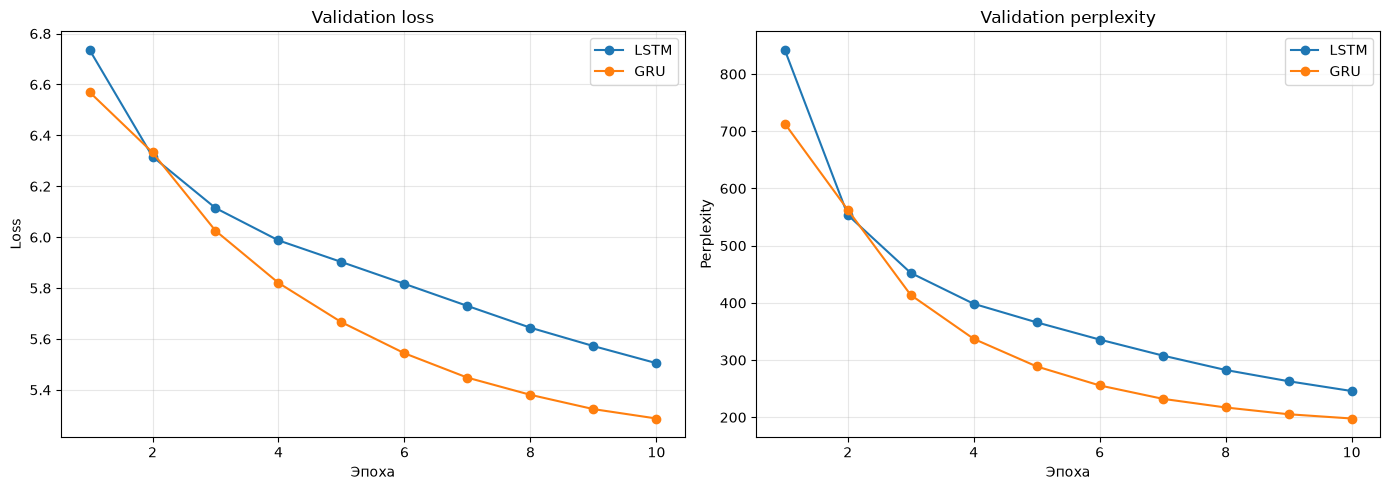

In [88]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    lstm_history["epoch"],
    lstm_history["validation_loss"],
    marker="o",
    label="LSTM",
)

axes[0].plot(
    gru_history["epoch"],
    gru_history["validation_loss"],
    marker="o",
    label="GRU",
)

axes[0].set_title("Validation loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    lstm_history["epoch"],
    lstm_history["validation_perplexity"],
    marker="o",
    label="LSTM",
)

axes[1].plot(
    gru_history["epoch"],
    gru_history["validation_perplexity"],
    marker="o",
    label="GRU",
)

axes[1].set_title("Validation perplexity")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Perplexity")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Вывод по графикам

Loss и perplexity обеих моделей стабильно снижаются. После второй эпохи GRU показывает лучшие результаты, чем LSTM. Рост validation loss отсутствует, поэтому признаков переобучения не наблюдается.

# 11 Оценка предобученной модели DistilGPT-2

Загрузим готовую модель `distilgpt2` и её BPE-токенизатор. Модель не будем обучать: оценим её качество на тестовой выборке WikiText-2 в исходном предобученном состоянии.

Загрузка модели

In [89]:
MODEL_NAME = "distilbert/distilgpt2"

gpt2_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

gpt2_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
).to(DEVICE)

gpt2_model.eval()

gpt2_parameters = count_parameters(gpt2_model)
gpt2_size_mb = model_size_mb(gpt2_model)

print(f"Модель: {MODEL_NAME}")
print(f"Параметров: {gpt2_parameters:,}")
print(f"Размер весов: {gpt2_size_mb:.2f} МБ")
print(f"Устройство: {DEVICE}")

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 472.30it/s]


Модель: distilbert/distilgpt2
Параметров: 81,912,576
Размер весов: 312.47 МБ
Устройство: cuda


Модель загружена: distilgpt2 имеет около 82 млн параметров и занимает 312 МБ - она значительно крупнее LSTM и GRU.
Теперь считаем perplexity на полном тестовом тексте скользящим окном.


## 11.2 Perplexity DistilGPT-2 на тестовой выборке

Контекстное окно `distilgpt2` ограничено 1024 токенами. Поэтому длинный тестовый текст будет обработан частями с перекрытием. Loss учитывается только для новых токенов каждого окна.

In [90]:
# Объединяем исходные непустые тестовые блоки
gpt2_test_text = "\n\n".join(
    text.strip()
    for text in raw_dataset["test"]["text"]
    if text.strip()
)

gpt2_encodings = gpt2_tokenizer(
    gpt2_test_text,
    return_tensors="pt",
    add_special_tokens=False,
)

input_ids = gpt2_encodings["input_ids"]

MAX_LENGTH = gpt2_model.config.n_positions
STRIDE = 512

total_nll = 0.0
total_loss_tokens = 0
previous_end = 0

window_starts = range(
    0,
    input_ids.size(1),
    STRIDE,
)

for begin in tqdm(
    window_starts,
    desc="Оценка DistilGPT-2",
):
    end = min(
        begin + MAX_LENGTH,
        input_ids.size(1),
    )

    new_token_count = end - previous_end

    window_ids = input_ids[
        :,
        begin:end,
    ].to(DEVICE)

    target_ids = window_ids.clone()

    # Не считаем loss повторно для контекста
    target_ids[:, :-new_token_count] = -100

    with torch.inference_mode():
        output = gpt2_model(
            window_ids,
            labels=target_ids,
        )

    # GPT-2 предсказывает токен со второй позиции
    loss_token_count = int(
        (target_ids[:, 1:] != -100)
        .sum()
        .item()
    )

    total_nll += (
        output.loss.item()
        * loss_token_count
    )

    total_loss_tokens += loss_token_count
    previous_end = end

    if end == input_ids.size(1):
        break

gpt2_test_loss = total_nll / total_loss_tokens
gpt2_test_ppl = math.exp(gpt2_test_loss)

print(f"Тестовых BPE-токенов: {total_loss_tokens:,}")
print(f"DistilGPT-2 test loss: {gpt2_test_loss:.4f}")
print(f"DistilGPT-2 test PPL: {gpt2_test_ppl:.2f}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (283633 > 1024). Running this sequence through the model will result in indexing errors
Оценка DistilGPT-2: 100%|█████████▉| 552/554 [00:15<00:00, 35.56it/s]

Тестовых BPE-токенов: 283,632
DistilGPT-2 test loss: 3.6401
DistilGPT-2 test PPL: 38.10


### Вывод

DistilGPT-2 показала test perplexity 38,1 на 283 632 BPE-токенах. Модель работает значительно лучше рекуррентных моделей, поскольку была предварительно обучена на большом текстовом корпусе.

При этом DistilGPT-2 содержит около 82 млн параметров и занимает 312 МБ - примерно в 6,8 раза больше GRU. Значения perplexity нельзя сравнивать напрямую, поскольку DistilGPT-2 использует BPE-токенизацию, а LSTM и GRU - пословную токенизацию.

## Дополнительный эксперимент: обучение GRU в течение 20 эпох

Проверим, продолжает ли validation perplexity снижаться после десятой эпохи. Эксперимент выполняется отдельно и пока не используется в итоговом сравнении.

In [91]:
set_seed(SEED)

gru_model_20 = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="GRU",
).to(DEVICE)

train_loader.generator.manual_seed(SEED)

gru_history_20 = fit_model(
    model=gru_model_20,
    train_loader=train_loader,
    validation_loader=validation_loader,
    epochs=20,
    learning_rate=0.001,
    clip_value=1.0,

    # Практически отключаем раннюю остановку,
    # чтобы увидеть все 20 эпох
    patience=20,
)

torch.save(
    gru_model_20.state_dict(),
    CHECKPOINT_DIR / "experimental_gru_20.pt",
)

gru_history_20.round(3)

Эпоха 01 | train loss: 7.0839 | train PPL: 1192.67 | val loss: 6.5703 | val PPL: 713.58 | время: 25.2 сек.


Эпоха 02 | train loss: 6.7148 | train PPL: 824.55 | val loss: 6.3330 | val PPL: 562.82 | время: 25.8 сек.


Эпоха 03 | train loss: 6.4376 | train PPL: 624.91 | val loss: 6.0254 | val PPL: 413.82 | время: 25.8 сек.


Эпоха 04 | train loss: 6.1736 | train PPL: 479.90 | val loss: 5.8204 | val PPL: 337.09 | время: 25.8 сек.


Эпоха 05 | train loss: 5.9685 | train PPL: 390.90 | val loss: 5.6660 | val PPL: 288.87 | время: 26.3 сек.


...

Эпоха 17 | train loss: 4.8219 | train PPL: 124.20 | val loss: 5.1874 | val PPL: 179.00 | время: 25.1 сек.


Эпоха 18 | train loss: 4.7792 | train PPL: 119.01 | val loss: 5.1803 | val PPL: 177.74 | время: 26.8 сек.


Эпоха 19 | train loss: 4.7408 | train PPL: 114.52 | val loss: 5.1822 | val PPL: 178.08 | время: 27.0 сек.


Эпоха 20 | train loss: 4.7051 | train PPL: 110.51 | val loss: 5.1803 | val PPL: 177.74 | время: 26.8 сек.


,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,epoch_time
0,1,7.084,1192.666,6.570,713.575,25.213
1,2,6.715,824.553,6.333,562.819,25.798
2,3,6.438,624.905,6.025,413.819,25.772
3,4,6.174,479.896,5.820,337.092,25.829
4,5,5.968,390.900,5.666,288.869,26.334
5,6,5.788,326.214,5.544,255.667,26.296
6,7,5.626,277.563,5.448,232.315,26.038
7,8,5.486,241.300,5.381,217.151,25.723
8,9,5.369,214.745,5.325,205.308,25.988
9,10,5.268,193.973,5.288,197.869,25.638


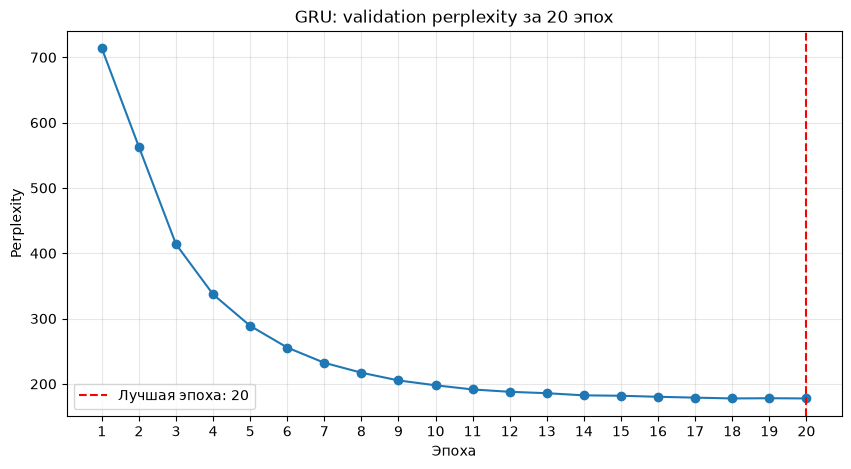

Лучший результат за 10 эпох: 197.87
Лучший результат за 20 эпох: 177.74


In [95]:
best_epoch_20 = int(
    gru_history_20.loc[
        gru_history_20[
            "validation_perplexity"
        ].idxmin(),
        "epoch",
    ]
)

best_val_ppl_20 = gru_history_20[
    "validation_perplexity"
].min()

plt.figure(figsize=(10, 5))

plt.plot(
    gru_history_20["epoch"],
    gru_history_20["validation_perplexity"],
    marker="o",
)

plt.axvline(
    best_epoch_20,
    color="red",
    linestyle="--",
    label=f"Лучшая эпоха: {best_epoch_20}",
)

plt.title("GRU: validation perplexity за 20 эпох")
plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.xticks(gru_history_20["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(
    f"Лучший результат за 10 эпох: "
    f"{gru_history['validation_perplexity'].min():.2f}"
)

print(
    f"Лучший результат за 20 эпох: "
    f"{best_val_ppl_20:.2f}"
)

 Дополнительный эксперимент

Увеличение числа эпох с 10 до 20 снизило validation perplexity GRU с 197,87 до 177,74 - примерно на 10,2%. Основное улучшение произошло до 15-й эпохи, после чего кривая приблизилась к плато. 

## Дополнительный эксперимент: обучение LSTM в течение 20 эпох

Проверим, насколько изменится validation perplexity LSTM при увеличении продолжительности обучения с 10 до 20 эпох. Эксперимент выполняется отдельно и не перезаписывает основную модель.

In [92]:
set_seed(SEED)

lstm_model_20 = RecurrentLanguageModel(
    **MODEL_CONFIG,
    rnn_type="LSTM",
).to(DEVICE)

train_loader.generator.manual_seed(SEED)

lstm_history_20 = fit_model(
    model=lstm_model_20,
    train_loader=train_loader,
    validation_loader=validation_loader,
    epochs=20,
    learning_rate=0.001,
    clip_value=1.0,
    patience=20,
)

torch.save(
    lstm_model_20.state_dict(),
    CHECKPOINT_DIR / "experimental_lstm_20.pt",
)

lstm_history_20.round(3)

Эпоха 01 | train loss: 7.1574 | train PPL: 1283.51 | val loss: 6.7363 | val PPL: 842.48 | время: 25.1 сек.


Эпоха 02 | train loss: 6.7351 | train PPL: 841.44 | val loss: 6.3167 | val PPL: 553.76 | время: 24.8 сек.


Эпоха 03 | train loss: 6.4451 | train PPL: 629.61 | val loss: 6.1146 | val PPL: 452.40 | время: 24.5 сек.


Эпоха 04 | train loss: 6.2762 | train PPL: 531.76 | val loss: 5.9874 | val PPL: 398.40 | время: 25.6 сек.


Эпоха 05 | train loss: 6.1571 | train PPL: 472.08 | val loss: 5.9025 | val PPL: 365.94 | время: 26.0 сек.


...

Эпоха 17 | train loss: 5.0850 | train PPL: 161.58 | val loss: 5.2620 | val PPL: 192.87 | время: 24.8 сек.


Эпоха 18 | train loss: 5.0337 | train PPL: 153.50 | val loss: 5.2421 | val PPL: 189.06 | время: 25.7 сек.


Эпоха 19 | train loss: 4.9865 | train PPL: 146.42 | val loss: 5.2330 | val PPL: 187.36 | время: 26.6 сек.


Эпоха 20 | train loss: 4.9433 | train PPL: 140.24 | val loss: 5.2243 | val PPL: 185.73 | время: 26.0 сек.


,epoch,train_loss,train_perplexity,validation_loss,validation_perplexity,epoch_time
0,1,7.157,1283.508,6.736,842.479,25.132
1,2,6.735,841.436,6.317,553.757,24.804
2,3,6.445,629.609,6.115,452.398,24.531
3,4,6.276,531.763,5.987,398.396,25.606
4,5,6.157,472.078,5.902,365.937,25.998
5,6,6.054,425.717,5.817,335.853,25.536
6,7,5.946,382.039,5.730,307.934,25.543
7,8,5.833,341.424,5.644,282.681,24.410
8,9,5.726,306.738,5.572,263.020,25.025
9,10,5.626,277.512,5.505,245.913,26.959


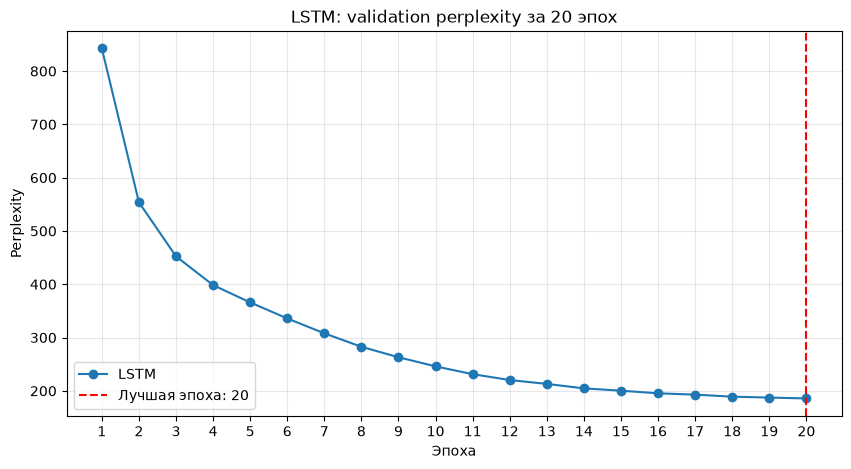

Лучший результат за 10 эпох: 245.91
Лучший результат за 20 эпох: 185.73
Улучшение: 24.47%


In [93]:
best_lstm_epoch_20 = int(
    lstm_history_20.loc[
        lstm_history_20[
            "validation_perplexity"
        ].idxmin(),
        "epoch",
    ]
)

best_lstm_val_ppl_20 = lstm_history_20[
    "validation_perplexity"
].min()

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history_20["epoch"],
    lstm_history_20["validation_perplexity"],
    marker="o",
    label="LSTM",
)

plt.axvline(
    best_lstm_epoch_20,
    color="red",
    linestyle="--",
    label=f"Лучшая эпоха: {best_lstm_epoch_20}",
)

plt.title("LSTM: validation perplexity за 20 эпох")
plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.xticks(lstm_history_20["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

lstm_ppl_10 = lstm_history[
    "validation_perplexity"
].min()

improvement_percent = (
    (lstm_ppl_10 - best_lstm_val_ppl_20)
    / lstm_ppl_10
    * 100
)

print(
    f"Лучший результат за 10 эпох: "
    f"{lstm_ppl_10:.2f}"
)

print(
    f"Лучший результат за 20 эпох: "
    f"{best_lstm_val_ppl_20:.2f}"
)

print(
    f"Улучшение: "
    f"{improvement_percent:.2f}%"
)

In [94]:
lstm_20_test_loss, lstm_20_test_ppl = evaluate_model(
    lstm_model_20,
    test_loader,
    criterion,
)

gru_20_test_loss, gru_20_test_ppl = evaluate_model(
    gru_model_20,
    test_loader,
    criterion,
)

print(
    f"LSTM 20 эпох — test PPL: "
    f"{lstm_20_test_ppl:.2f}"
)

print(
    f"GRU 20 эпох — test PPL: "
    f"{gru_20_test_ppl:.2f}"
)

LSTM 20 эпох — test PPL: 174.47
GRU 20 эпох — test PPL: 166.48


# 12 Качественное сравнение предсказаний

Получим пять наиболее вероятных следующих токенов LSTM, GRU и DistilGPT-2 для одинаковых текстовых контекстов.

Функция для LSTM и GRU

In [100]:
final_lstm_model = lstm_model_20
final_gru_model = gru_model_20


@torch.inference_mode()
def predict_rnn_tokens(
    model,
    context,
    top_k=5,
):
    model.eval()

    tokens = tokenize(
        clean_text(context)
    )

    token_ids = [
        token_to_id.get(token, UNK_ID)
        for token in tokens
    ][-SEQ_LEN:]

    model_device = next(
        model.parameters()
    ).device

    x = torch.tensor(
        [token_ids],
        dtype=torch.long,
        device=model_device,
    )

    logits, _ = model(x)
    next_logits = logits[0, -1].clone()

    # Не показываем служебные токены
    next_logits[UNK_ID] = float("-inf")
    next_logits[EOS_ID] = float("-inf")

    probabilities = torch.softmax(
        next_logits,
        dim=-1,
    )

    top_probabilities, top_indices = torch.topk(
        probabilities,
        k=top_k,
    )

    return [
        (
            id_to_token[token_id],
            probability,
        )
        for token_id, probability in zip(
            top_indices.tolist(),
            top_probabilities.tolist(),
        )
    ]

Функция для DistilGPT-2

In [101]:
@torch.inference_mode()
def predict_gpt2_tokens(
    context,
    top_k=5,
):
    gpt2_model.eval()

    encoded = gpt2_tokenizer(
        context,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(DEVICE)

    output = gpt2_model(**encoded)
    next_logits = output.logits[0, -1]

    probabilities = torch.softmax(
        next_logits,
        dim=-1,
    )

    candidate_probabilities, candidate_indices = (
        torch.topk(
            probabilities,
            k=top_k * 5,
        )
    )

    predictions = []
    used_tokens = set()

    for token_id, probability in zip(
        candidate_indices.tolist(),
        candidate_probabilities.tolist(),
    ):
        token = gpt2_tokenizer.decode(
            [token_id]
        ).strip()

        if not token or token in used_tokens:
            continue

        used_tokens.add(token)
        predictions.append(
            (token, probability)
        )

        if len(predictions) == top_k:
            break

    return predictions

Сравнение на восьми контекстах

In [102]:
prediction_contexts = [
    "the president of the",
    "the united states",
    "the game was",
    "he was born in",
    "the company announced",
    "the city of",
    "during the war",
    "the album was released",
]


def format_predictions(predictions):
    return ", ".join(
        token
        for token, probability in predictions
    )


prediction_rows = []

for context in prediction_contexts:
    prediction_rows.append(
        {
            "context": context,
            "LSTM": format_predictions(
                predict_rnn_tokens(
                    final_lstm_model,
                    context,
                )
            ),
            "GRU": format_predictions(
                predict_rnn_tokens(
                    final_gru_model,
                    context,
                )
            ),
            "DistilGPT-2": format_predictions(
                predict_gpt2_tokens(context)
            ),
        }
    )

predictions_df = pd.DataFrame(
    prediction_rows
)

pd.set_option(
    "display.max_colwidth",
    None,
)

predictions_df

,context,LSTM,GRU,DistilGPT-2
0,the president of the,"church, city, war, song, united","republic, war, church, united, soviets","United, U, US, European, world"
1,the united states,",, ., and, in, as",",, ., in, and, on","of, ,, ., and, are"
2,the game was,"released, a, the, not, also","released, a, the, not, also","a, released, not, the, played"
3,he was born in,"the, a, his, november, march","the, a, his, an, march","the, a, New, London, 18"
4,the company announced,"that, the, it, a, ,","that, the, to, a, it","on, today, in, the, that"
5,the city of,"the, pennsylvania, a, scientology, new","the, pennsylvania, maryland, omaha, newark","New, London, Toronto, San, Chicago"
6,during the war,",, ., in, of, 's","., ,, of, in, and","on, ,, ., in, against"
7,the album was released,"in, on, as, by, at","in, on, by, at, .","in, on, by, as, at"


### Вывод по примерам

DistilGPT-2 чаще предлагает смысловые продолжения, связанные с контекстом. Например, после `the city of` она предлагает названия городов, а после `he was born in` — места и даты. GRU и LSTM также дают грамматически допустимые варианты, но их предсказания менее точны. Среди рекуррентных моделей результаты GRU выглядят немного лучше.

### Сравнение скорости предсказания

Измерим медианное время прямого прохода при `batch_size = 1` на CPU. Результат зависит от процессора компьютера и используется только для относительного сравнения моделей.

In [103]:
# Находим достаточно длинный тестовый текст
benchmark_text = next(
    text
    for text in cleaned_dataset["test"]["text"]
    if len(tokenize(text)) >= SEQ_LEN
)

benchmark_tokens = tokenize(
    benchmark_text
)[:SEQ_LEN]

benchmark_context = " ".join(
    benchmark_tokens
)

# Вход для LSTM и GRU
rnn_benchmark_ids = [
    token_to_id.get(token, UNK_ID)
    for token in benchmark_tokens
]

rnn_benchmark_input = torch.tensor(
    [rnn_benchmark_ids],
    dtype=torch.long,
)

# Вход для DistilGPT-2
gpt2_benchmark_input = gpt2_tokenizer(
    benchmark_context,
    return_tensors="pt",
    add_special_tokens=False,
)["input_ids"]

print(
    f"RNN-токенов: "
    f"{rnn_benchmark_input.shape[1]}"
)

print(
    f"GPT-2 BPE-токенов: "
    f"{gpt2_benchmark_input.shape[1]}"
)

RNN-токенов: 64
GPT-2 BPE-токенов: 70


Для сравнения скорости выберем один достаточно длинный текст из тестовой выборки. LSTM и GRU получат последовательность из 64 токенов. Тот же текст будет отдельно обработан BPE-токенизатором DistilGPT-2, поэтому количество её входных токенов может отличаться.

Для устойчивой оценки сначала выполним пять запусков, а затем измерим время 30 предсказаний. Основным показателем будет медианное время, поскольку оно меньше зависит от случайных задержек системы.

In [104]:
def measure_latency(
    inference_function,
    warmup_runs=5,
    measured_runs=30,
):
    # Прогрев
    for _ in range(warmup_runs):
        inference_function()

    times = []

    for _ in range(measured_runs):
        start = time.perf_counter()
        inference_function()
        times.append(
            (time.perf_counter() - start) * 1000
        )

    return {
        "median_ms": np.median(times),
        "mean_ms": np.mean(times),
    }

Эта функция измеряет время одного предсказания в миллисекундах.
- warmup_runs = 5 - пять прогревочных запусков. Они не учитываются, поскольку первый запуск обычно медленнее.
- measured_runs = 30 - модель запускается 30 раз для более устойчивого результата.
- median_ms - медианное время; меньше зависит от случайных задержек.
- mean_ms - среднее время всех запусков.

Перенесём все модели на CPU и измерим время одного прямого прохода. Такой тест приблизительно отражает относительную скорость моделей на устройстве без GPU. Меньшее время означает более быстрый вывод подсказки пользователю.

In [105]:
# Временно переносим модели на CPU
final_lstm_model = final_lstm_model.cpu().eval()
final_gru_model = final_gru_model.cpu().eval()
gpt2_model = gpt2_model.cpu().eval()

with torch.inference_mode():
    lstm_latency = measure_latency(
        lambda: final_lstm_model(
            rnn_benchmark_input
        )
    )

    gru_latency = measure_latency(
        lambda: final_gru_model(
            rnn_benchmark_input
        )
    )

    gpt2_latency = measure_latency(
        lambda: gpt2_model(
            input_ids=gpt2_benchmark_input,
            use_cache=False,
        )
    )

latency_df = pd.DataFrame(
    [
        {
            "model": "LSTM",
            **lstm_latency,
        },
        {
            "model": "GRU",
            **gru_latency,
        },
        {
            "model": "DistilGPT-2",
            **gpt2_latency,
        },
    ]
).round(2)

latency_df

,model,median_ms,mean_ms
0,LSTM,14.78,15.10
1,GRU,23.11,23.79
2,DistilGPT-2,96.25,97.48


### Вывод по скорости

На текущем CPU самое быстрое предсказание показала LSTM — 14,78 мс. GRU потребовалось 23,11 мс, а DistilGPT-2 — 96,25 мс. Результаты отражают относительную скорость моделей на данном компьютере и не являются прямым замером на смартфоне.

После получения таблицы модели вернем GPU:

In [107]:
final_lstm_model = final_lstm_model.to(DEVICE)
final_gru_model = final_gru_model.to(DEVICE)
gpt2_model = gpt2_model.to(DEVICE)

## Итоговое сравнение моделей

Соберём основные результаты трёх моделей в одну таблицу: количество параметров, размер весов, perplexity, время обучения и скорость предсказания на CPU.

Perplexity LSTM и GRU можно сравнивать напрямую, поскольку они используют одинаковую пословную токенизацию. Значение DistilGPT-2 приведено отдельно, так как модель использует BPE-токенизацию.

In [110]:
# Финальная оценка моделей после 20 эпох
criterion = nn.CrossEntropyLoss()

lstm_final_test_loss, lstm_final_test_ppl = (
    evaluate_model(
        final_lstm_model,
        test_loader,
        criterion,
    )
)

gru_final_test_loss, gru_final_test_ppl = (
    evaluate_model(
        final_gru_model,
        test_loader,
        criterion,
    )
)

latency_lookup = latency_df.set_index(
    "model"
)["median_ms"]

final_comparison = pd.DataFrame(
    [
        {
            "model": "LSTM",
            "tokenizer": "Word-level",
            "parameters": count_parameters(
                final_lstm_model
            ),
            "size_mb": model_size_mb(
                final_lstm_model
            ),
            "val_ppl": lstm_history_20[
                "validation_perplexity"
            ].min(),
            "test_ppl": lstm_final_test_ppl,
            "epoch_time_sec": lstm_history_20[
                "epoch_time"
            ].median(),
            "cpu_latency_ms": latency_lookup["LSTM"],
        },
        {
            "model": "GRU",
            "tokenizer": "Word-level",
            "parameters": count_parameters(
                final_gru_model
            ),
            "size_mb": model_size_mb(
                final_gru_model
            ),
            "val_ppl": gru_history_20[
                "validation_perplexity"
            ].min(),
            "test_ppl": gru_final_test_ppl,
            "epoch_time_sec": gru_history_20[
                "epoch_time"
            ].median(),
            "cpu_latency_ms": latency_lookup["GRU"],
        },
        {
            "model": "DistilGPT-2",
            "tokenizer": "BPE",
            "parameters": gpt2_parameters,
            "size_mb": gpt2_size_mb,
            "val_ppl": np.nan,
            "test_ppl": gpt2_test_ppl,
            "epoch_time_sec": np.nan,
            "cpu_latency_ms": latency_lookup[
                "DistilGPT-2"
            ],
        },
    ]
).round(2)

final_comparison_display = (
    final_comparison
    .astype(object)
    .where(
        final_comparison.notna(),
        "-",
    )
)

final_comparison_display

,model,tokenizer,parameters,size_mb,val_ppl,test_ppl,epoch_time_sec,cpu_latency_ms
0,LSTM,Word-level,12281410,46.85,185.73,174.47,25.57,14.78
1,GRU,Word-level,12051010,45.97,177.74,166.48,25.81,23.11
2,DistilGPT-2,BPE,81912576,312.47,-,38.1,-,96.25


### Вывод

Среди рекуррентных моделей лучшее качество показала GRU: её test perplexity составила 166,48 против 174,47 у LSTM. GRU также немного компактнее - 45,97 МБ против 46,85 МБ.

LSTM оказалась быстрее на CPU: 14,78 мс против 23,11 мс у GRU. Поэтому LSTM предпочтительнее при строгих требованиях к задержке, а GRU - если важнее качество предсказаний и размер модели.

DistilGPT-2 показала test perplexity 38,10 в собственной BPE-токенизации и наиболее естественные продолжения текста. Однако она занимает 312,47 МБ и выполняет предсказание за 96,25 мс, поэтому значительно хуже подходит для локального запуска на мобильном устройстве.

# Итоговые выводы и рекомендации

В проекте были обучены и сравнены языковые модели LSTM и GRU, а также оценена предобученная DistilGPT-2.

Среди рекуррентных моделей лучшее качество показала GRU. После 20 эпох её test perplexity составила 166,48, тогда как у LSTM - 174,47. GRU также немного компактнее: 45,97 МБ против 46,85 МБ.

LSTM показала минимальное время предсказания на CPU - 14,78 мс. GRU потребовалось 23,11 мс, однако она обеспечила лучшее качество при немного меньшем размере.

DistilGPT-2 создаёт наиболее естественные продолжения и показала perplexity 38,10 в собственной BPE-токенизации. При этом модель содержит около 82 млн параметров, занимает 312,47 МБ и работает значительно медленнее рекуррентных моделей. Её perplexity нельзя напрямую сравнивать с LSTM и GRU из-за различий в токенизации.

Для локальной работы в мобильном мессенджере рекомендуется GRU как лучший баланс качества, размера и скорости. Если основным требованием является минимальная задержка, можно выбрать LSTM. DistilGPT-2 целесообразно использовать на сервере, когда качество важнее размера модели и требуется доступ к сети.

Перед внедрением необходимо дополнительно измерить скорость и расход памяти непосредственно на целевом смартфоне. Для уменьшения размера рекуррентной модели можно рассмотреть INT8-квантизацию.